In [ ]:
python ./svraster/train.py \
    --eval \
    --source_path /home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen \
    --model_path /home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04 \
    --lambda_normal_dmean 0.001 --lambda_normal_dmed 0.001 \
    --res_downscale 8 \
    --test_every 20 \
    --ss 1.0 \
    --n_iter 95000 \
    --init_n_level 5 \
    --adapt_every 4000 \
    --adapt_from 4000 \
    --prune_until 90000 \
    --subdivide_until 90000 \
    --subdivide_max_num 2000000 \
    --checkpoint_iterations 999 1999 2999 3999 4999 5999 6999 7999 8999 9999 \
                            10999 11999 12999 13999 14999 15999 16999 17999 18999 19999 \
                            20999 21999 22999 23999 24999 25999 26999 27999 28999 29999 \
                            30999 31999 32999 33999 34999 35999 36999 37999 38999 39999 \
                            40999 41999 42999 43999 44999 45999 46999 47999 48999 49999 \
                            50999 51999 52999 53999 54999 55999 56999 57999 58999 59999 \
                            60999 61999 62999 63999 64999 65999 66999 67999 68999 69999 \
                            70999 71999 72999 73999 74999 75999 76999 77999 78999 79999 \
                            80999 81999 82999 83999 84999 85999 86999 87999 88999 89999 \
                            90999 91999 92999 93999 94999 \
    --sh_degree_init 0 \
    --black_background \
    --sh_degree 0


#                             # 90999 91999 92999 93999 94999 95999 96999 97999 98999 99999 \
#                             # 100999 101999 102999 103999 104999 105999 106999 107999 108999 109999 \
#                             # 110999 111999 112999 113999 114999 115999 116999 117999 118999 119999 \
#                             # 120999 121999 122999 123999 124999 125999 126999 127999 128999 129999 \

# 00

In [1]:
import os
PROJECT_ROOT = "/home/dotamthuc-3090/Projects/ViewSynthesis/"
print("PROJECT_ROOT:", PROJECT_ROOT)

import sys
lib_decompre = "/home/dotamthuc-3090/Projects/ViewSynthesis/Differentiable3DPC-Decompression-and-Rendering"
sys.path.insert(0, lib_decompre)

lib_svraster = "/home/dotamthuc-3090/Projects/ViewSynthesis/svraster"
sys.path.insert(0, lib_svraster)

import time
import itertools
import numpy as np
import torch
from matplotlib.pylab import plt

from libs.dataloader.View import View, ViewCreator
from libs.dataloader.Scene import Scene

import decompress_render

from src.dataloader.data_pack import DataPack
from src.sparse_voxel_model import SparseVoxelModel
from src.config import cfg, update_argparser, update_config


torch.set_printoptions(
    precision=4,
    sci_mode=False,
    threshold=10000,    # Print the full array if it has fewer than 10000 elements
    linewidth=1000       # Number of characters per line
)
np.set_printoptions(
    precision=4,        # Number of digits of precision for floating point output
    suppress=False,      # Suppress scientific notation
    threshold=10000,    # Print the full array if it has fewer than 10000 elements
    linewidth=1000       # Number of characters per line
)

PROJECT_ROOT: /home/dotamthuc-3090/Projects/ViewSynthesis/


In [ ]:
def get_polynomials_coefs_sqrtinv(max_degree):
    list_b = [1]
    temp = 1
    for n in range(1, max_degree+1):
        temp *= (2 * n - 1) / (2 * n)
        list_b.append(temp)

    return np.array(list_b, np.float32)


def load_geometry_from_sparse_voxels_model(sourse_path, load_attribute_field=True):
    voxel_model_frame = SparseVoxelModel(
        n_samp_per_vox=1,
        sh_degree=0,
        ss=1.0,
        white_background=False,
        black_background=True,
    )
    voxel_model_frame.load(sourse_path)

    geometry_info = {}
    geometry_info["morton_code_tensor"] = voxel_model_frame.vox_morton_code.clone().detach()
    geometry_info["vox_roots_tensor"] = voxel_model_frame.vox_root.clone().detach()
    geometry_info["vox_length_tensor"] = voxel_model_frame.vox_size.clone().detach()
    geometry_info["vox2corners_tensor"] = voxel_model_frame.vox_key.clone().detach()
    geometry_info["vox_params_geo_tensor"] = voxel_model_frame.vox_conners_geo_params.clone().detach()

    if load_attribute_field:
        geometry_info["vox_params_color_tensor"] = voxel_model_frame.vox_static_rgbs.clone().detach()

    del voxel_model_frame
    torch.cuda.empty_cache()

    return geometry_info


class DensityField:
    def __init__(
        self,
        source_path,
        num_sample_per_voxel=1,
        load_attribute_field=True
    ):
        # CONFIG INFO
        self.num_sample_per_voxel = num_sample_per_voxel

        geometry_info = load_geometry_from_sparse_voxels_model(source_path, load_attribute_field)
        #### Define the Density Field
        self.voxel_morton_code = geometry_info["morton_code_tensor"]
        self.voxel_position    = geometry_info["vox_roots_tensor"]
        self.voxel_size        = geometry_info["vox_length_tensor"]
        self.voxel2corner      = geometry_info["vox2corners_tensor"]
        self.corner_geo_params = geometry_info["vox_params_geo_tensor"]
        self.num_voxels        = self.voxel_morton_code.shape[0]

        #### Define current Attribute Field
        if load_attribute_field:
            self.voxel_attribute_field = geometry_info["vox_params_color_tensor"]
        else:
            self.voxel_attribute_field = torch.full(
                [self.num_voxels, 3], 0.0, 
                dtype=torch.float32
            )
    
    def apply_phi(self, view_info):

        w, h = view_info.render_width, view_info.render_height

        camera_settings = decompress_render.renderer.CameraSettings(
            image_width=view_info.render_width, 
            image_height=view_info.render_height, 
            tanfovx=view_info.tanfovx, 
            tanfovy=view_info.tanfovy, 
            cx=view_info.cx,
            cy=view_info.cy,
            w2c_matrix=view_info.world2view.cuda(),
            c2w_matrix=view_info.view2world.cuda()
        )

        render_settings = decompress_render.renderer.RenderSettings(
            num_sample_per_vox=self.num_sample_per_voxel,
            bg_color=0.0,
            near=view_info.near,
            need_depth=False,
            track_max_w=False,
            debug=False,
        )

        out_color, _, _, _ = decompress_render.renderer.rasterize_voxels_main(
            camera_settings=camera_settings,
            render_settings=render_settings,
            morton_code=self.voxel_morton_code,
            vox_roots=self.voxel_position,
            vox_length=self.voxel_size,
            vox2corners=self.voxel2corner,
            vox_params_geo=self.corner_geo_params,
            vox_params_color=self.voxel_attribute_field,
        )

        rendered_image = torch.permute(out_color.clamp(0, 1), dims=(1, 2, 0)).detach()

        return rendered_image
    
    
    def apply_phi_with_F(self, voxel_attribute, view_info):

        if voxel_attribute.shape != (self.num_voxels, 3):
            raise Exception(f"Expect voxel_attribute in is static voxels color ({self.num_voxels}, 3) but got", voxel_attribute.shape)

        w, h = view_info.render_width, view_info.render_height
        camera_settings = decompress_render.renderer.CameraSettings(
            image_width=view_info.render_width, 
            image_height=view_info.render_height, 
            tanfovx=view_info.tanfovx, 
            tanfovy=view_info.tanfovy, 
            cx=view_info.cx,
            cy=view_info.cy,
            w2c_matrix=view_info.world2view.cuda(),
            c2w_matrix=view_info.view2world.cuda()
        )

        render_settings = decompress_render.renderer.RenderSettings(
            num_sample_per_vox=self.num_sample_per_voxel,
            bg_color=0.0,
            near=view_info.near,
            need_depth=False,
            track_max_w=False,
            debug=False,
        )

        out_color, _, _, _ = decompress_render.renderer.rasterize_voxels_main(
            camera_settings=camera_settings,
            render_settings=render_settings,
            morton_code=self.voxel_morton_code,
            vox_roots=self.voxel_position,
            vox_length=self.voxel_size,
            vox2corners=self.voxel2corner,
            vox_params_geo=self.corner_geo_params,
            vox_params_color=voxel_attribute, # use as input voxel_attribute 
        )

        rendered_image = torch.permute(out_color.clamp(0, 1), dims=(1, 2, 0))

        return rendered_image

    def apply_A_transpose(
            self,
            lowres_denfield,
            decoded_attribute_field,
            scene_dataset,
            optim_opt={}
        ):

        MSE_calculator = torch.nn.MSELoss()

        approx_attribute_field = torch.nn.Parameter(torch.full(
            [self.num_voxels, 3], 0.5, 
            dtype=torch.float32, device="cuda"
        ))
        optimizer = torch.optim.Adam([approx_attribute_field], lr=optim_opt.get("lr", 0.001))
        train_views = scene_dataset.get_train_views()
        test_views = scene_dataset.get_encoder_views()

        i=0
        for loop in range(optim_opt.get("num_scene_loop", 30)):
            k=0
            for view in train_views:
                ##
                optimizer.zero_grad()
                true_low_res_img   = lowres_denfield.apply_phi_with_F(decoded_attribute_field, view)
                approx_low_res_img = self.apply_phi_with_F(approx_attribute_field, view)
                ###
                mse_val = MSE_calculator(approx_low_res_img, true_low_res_img)
                mse_val.backward()
                ###

                if (i%500==0):
                    list_mse = []
                    for test_v in test_views:
                        true_low_res_img   = lowres_denfield.apply_phi_with_F(decoded_attribute_field, test_v).detach()
                        approx_low_res_img = self.apply_phi_with_F(approx_attribute_field, test_v).detach()
                        mse_test = MSE_calculator(approx_low_res_img, true_low_res_img).detach()
                        list_mse.append(mse_test.cpu())
                    print(f"Apply_A_transpose: loop = {loop, k} iter = {i} psnr={-10 * np.log10(np.mean(list_mse))}")
                    
                optimizer.step()
                i+=1
                k+=1

        output = approx_attribute_field.detach()
        list_mse = []
        for test_v in test_views:
            true_low_res_img   = lowres_denfield.apply_phi_with_F(decoded_attribute_field, test_v).detach()
            approx_low_res_img = self.apply_phi_with_F(output, test_v).detach()
            mse_test = MSE_calculator(approx_low_res_img, true_low_res_img).detach()
            list_mse.append(mse_test.cpu())
        print(f"Apply_A_transpose output: psnr={-10 * np.log10(np.mean(list_mse))}")
        
        # Cleaning
        optimizer.zero_grad()
        del optimizer
        torch.cuda.empty_cache()

        return output


    @torch.compiler.disable
    def apply_subview_phiTphi_with_F(self, voxel_attribute, view_info):

        w, h = view_info.render_width, view_info.render_height
        camera_settings = decompress_render.renderer.CameraSettings(
            image_width=view_info.render_width, 
            image_height=view_info.render_height, 
            tanfovx=view_info.tanfovx, 
            tanfovy=view_info.tanfovy, 
            cx=view_info.cx,
            cy=view_info.cy,
            w2c_matrix=view_info.world2view.cuda(),
            c2w_matrix=view_info.view2world.cuda()
        )

        render_settings = decompress_render.renderer.RenderSettings(
            num_sample_per_vox=self.num_sample_per_voxel,
            bg_color=0.0,
            near=view_info.near,
            need_depth=False,
            track_max_w=False,
            debug=False,
        )

        out_transformed_attribute = decompress_render.renderer.geometry_attention_transform_main(
            camera_settings=camera_settings,
            render_settings=render_settings,
            morton_code=self.voxel_morton_code,
            vox_roots=self.voxel_position,
            vox_length=self.voxel_size,
            vox2corners=self.voxel2corner,
            vox_params_geo=self.corner_geo_params,
            vox_params_attribute=voxel_attribute, # use as input voxel_attribute 
        )

        return out_transformed_attribute
    
    
    # @torch.compiler.disable
    def apply_full_phiTphi_with_F(self, voxel_attribute, scene_dataset):

        if voxel_attribute.shape != (self.num_voxels, 3):
            raise Exception(f"Expect voxel_attribute in is static ({self.num_voxels}, 3) but got", voxel_attribute.shape)

        list_views = scene_dataset.get_encoder_views()
        transformed_attribute = torch.full(
            [self.num_voxels, 3], 0.0, 
            dtype=torch.float32, device="cuda"
        )
        # vi = 0
        for view in list_views:
            # s = time.time()
            transformed_attribute = transformed_attribute + self.apply_subview_phiTphi_with_F(voxel_attribute, view)
            # print(f"++++ Apply_full_phiTphi_with_F: finished view {vi} in {time.time()-s}")
            # vi += 1

        return transformed_attribute


    # @torch.compiler.disable
    def apply_scaled_rotation_phiTphi(self, voxel_attribute, scene_dataset, rotation_opt={}):
        output = torch.full(
            [self.num_voxels, 3], 0.0, 
            dtype=torch.float32, device="cuda"
        )

        diagonal = self.apply_full_phiTphi_with_F(
            torch.ones_like(voxel_attribute), 
            scene_dataset
        ).detach()

        sqrtinv_diagonal = torch.where(
            diagonal>0.0,
            1.0 / torch.sqrt(diagonal),
            1.0
        )
        # sqrtinv_diagonal = torch.ones_like(diagonal)

        max_degree = rotation_opt.get("max_degree", 10)
        poly_coefs_sqrtinv = get_polynomials_coefs_sqrtinv(max_degree)
        signal = voxel_attribute

        muy_phi = rotation_opt.get("muy_phi", 1.0)
        output = signal * torch.tensor(poly_coefs_sqrtinv[0] * np.sqrt(2*muy_phi))
        temp_val = signal
        
        for p in range(1, len(poly_coefs_sqrtinv)):
            s = time.time()
            Xb = self.apply_full_phiTphi_with_F(
                temp_val*sqrtinv_diagonal,
                scene_dataset
            ) * sqrtinv_diagonal

            temp_val = temp_val - torch.tensor(2 * muy_phi) * Xb
            output = output + temp_val * torch.tensor(poly_coefs_sqrtinv[p] * np.sqrt(2*muy_phi))
            # print(f"+++ Apply_scaled_rotation_phiTphi: finished degree {p} in {time.time() - s}")

        output = output * sqrtinv_diagonal
        return output

    # @torch.compiler.disable
    # def apply_scaled_rotation_phiTphi_transpose(self, voxel_attribute, scene_dataset, rotation_opt={}):
    #     output = torch.full(
    #         [self.num_voxels, 3], 0.0, 
    #         dtype=torch.float32, device="cuda"
    #     )

    #     diagonal = self.apply_full_phiTphi_with_F(
    #         torch.ones_like(voxel_attribute), 
    #         scene_dataset
    #     ).detach()

    #     sqrtinv_diagonal = torch.where(
    #         diagonal>0.0,
    #         1.0 / torch.sqrt(diagonal),
    #         1.0
    #     )
    #     # sqrtinv_diagonal = torch.ones_like(diagonal)

    #     max_degree = rotation_opt.get("max_degree", 10)
    #     poly_coefs_sqrtinv = get_polynomials_coefs_sqrtinv(max_degree)
    #     signal = voxel_attribute * sqrtinv_diagonal

    #     muy_phi = rotation_opt.get("muy_phi", 1.0)
    #     output = signal * torch.tensor(poly_coefs_sqrtinv[0] * np.sqrt(2*muy_phi))
    #     temp_val = signal
        
    #     for p in range(1, max_degree):
    #         s = time.time()
    #         Xb = self.apply_full_phiTphi_with_F(
    #             temp_val*sqrtinv_diagonal,
    #             scene_dataset
    #         ) * sqrtinv_diagonal

    #         temp_val = temp_val - torch.tensor(2 * muy_phi) * Xb
    #         output = output + temp_val * torch.tensor(poly_coefs_sqrtinv[p] * np.sqrt(2*muy_phi))
    #         # print(f"+++ Apply_scaled_rotation_phiTphi: finished degree {p} in {time.time() - s}")

    #     output = output
    #     return output

    def decoding_attribute_field(self, encoded_coefs, scene_dataset, rotation_opt={}):
        decoded_attribute_field = self.apply_scaled_rotation_phiTphi(
            encoded_coefs,
            scene_dataset,
            rotation_opt
        )
        return decoded_attribute_field

    def simulate_quantization(self, coefs, delta):

        with torch.no_grad():
            index_bins = (coefs / delta)
            ind_noise = torch.round(index_bins) - index_bins

        x_hat = coefs + ind_noise * delta
        return x_hat

    def encoding_attribute_field(self, enc_params, voxel_attribute, scene_dataset, rotation_opt={}, encoding_opts={}):

        print(f"Start Encoding Process custom_encoding_opts={encoding_opts}")
        MSE_calculator = torch.nn.MSELoss()
        dmode=encoding_opts.get("dmode", "coef_space")

        lambda_rate, log2_deltaQ, encoded_coefs, log2_spread_b = enc_params
        lr = encoding_opts.get("lr", 0.001)
        optimizer = torch.optim.Adam([encoded_coefs, log2_spread_b, log2_deltaQ], lr=lr, eps=1e-20)
        train_views = scene_dataset.get_train_views()
        test_views = scene_dataset.get_encoder_views()

        i=0
        num_loop = encoding_opts.get("num_loop", 30)
        for loop in range(num_loop):
            k=0
            for view in train_views:
                optimizer.zero_grad()
                
                decoded_attribute_field = self.apply_scaled_rotation_phiTphi(
                    self.simulate_quantization(encoded_coefs, torch.exp2(log2_deltaQ)),
                    scene_dataset,
                    rotation_opt
                )
                
                ###
                if dmode=="render_space":
                    true_rendered_img_field   = self.apply_phi_with_F(voxel_attribute, view)
                    approx_rendered_img_field = self.apply_phi_with_F(decoded_attribute_field, view)
                    mse = MSE_calculator(true_rendered_img_field, approx_rendered_img_field)
                elif dmode=="coef_space":
                    mse = MSE_calculator(voxel_attribute, decoded_attribute_field)
                
                if lambda_rate > 0:
                    rate = (torch.abs(encoded_coefs) / (torch.exp2(log2_spread_b) * np.log(2)) + log2_spread_b - log2_deltaQ + 1)
                    loss = mse + lambda_rate * rate.mean()
                else:
                    loss = mse

                ###
                loss.backward()
                optimizer.step()
                if (i%100==0):
                    with torch.no_grad():
                        list_mse = []
                        rate_test = (torch.abs(encoded_coefs) / (torch.exp2(log2_spread_b) * np.log(2)) + log2_spread_b - log2_deltaQ + 1)
                        mse_test_02 = MSE_calculator(voxel_attribute, decoded_attribute_field).detach()
                        for test_v in test_views:
                            true_rendered_img_field   = self.apply_phi_with_F(voxel_attribute, test_v).detach()
                            approx_rendered_img_field = self.apply_phi_with_F(decoded_attribute_field, test_v).detach()
                            mse_test_01 = MSE_calculator(true_rendered_img_field, approx_rendered_img_field).detach()
                            list_mse.append(mse_test_01.cpu())
                    print((
                        f"Encoding_attribute_field: TESTING loop = {loop, k} iter = {i} "
                        f"psnr={-10 * np.log10(np.mean(list_mse))} "
                        f"psnr_delta_field={-10 * np.log10(mse_test_02.cpu())} "
                        f"rate={rate_test.mean().detach()} "
                        f"spread={torch.exp2(log2_spread_b).detach().cpu().numpy()} "
                        f"deltaQ={torch.exp2(log2_deltaQ).detach().cpu().numpy()} "
                    ))

                ###
                i+=1
                k+=1

        output = encoded_coefs.detach()
        
        # Cleaning
        optimizer.zero_grad()
        del optimizer
        torch.cuda.empty_cache()

        return output

class MultiScaleSplatsEncoder:
    def __init__(
        self,
        scene_dataset_source_path,
        list_density_field_paths,
        deltaQ=0.005,
        lambda_rate=0.00001,
        list_spread_b_init=[1.0, 0.2, 0.085, 0.05, 0.035, 0.025, 0.02, 0.015], 
        num_sample_per_voxel=1,
        scene_loader_opt={
            "res_downscale": 8,
            "res_width": 0,
            "encoder_view_every": 20
        },
        A_transpose_opt={
            "lr": 0.001,
            "num_scene_loop": 30,
        },
        rotation_opt={
            "max_degree": 5,
            "muy_phi": 1.0,
        },
        encoding_opts={
            "lr": 0.005,
            "num_loop": 20,
        },
        lowpass_rotation_opt = {
            "max_degree": 2,
            "muy_phi": 0.9,
        },
        lowpass_encoding_opts={
            "lr": 0.005,
            "num_loop": 45,
        }
    ):

        self.list_density_field = []
        for path in list_density_field_paths:
            self.list_density_field.append(
                DensityField(path, num_sample_per_voxel, load_attribute_field=True)
            )

        self.scene_dataset = Scene(
            scene_dataset_source_path, image_dir_name="images",
            res_downscale=scene_loader_opt["res_downscale"],
            res_width=scene_loader_opt["res_width"],
            encoder_view_every=scene_loader_opt["encoder_view_every"],
        )
        self.lambda_rate = lambda_rate

        self.lowpass_rotation_opt  = lowpass_rotation_opt
        self.lowpass_encoding_opts = lowpass_encoding_opts
        self.A_transpose_opt       = A_transpose_opt
        self.rotation_opt          = rotation_opt
        self.encoding_opts         = encoding_opts

        ###############################################################
        ###############################################################
        ###############################################################
        
        list_learned_coefs = []
        list_learned_logspread = []
        L = len(self.list_density_field)
        for i in range(L):
            list_learned_coefs.append(
                torch.nn.Parameter(torch.full(
                    [self.list_density_field[i].num_voxels, 3], 0.0, 
                    dtype=torch.float32, device="cuda"
                ))
            )
            list_learned_logspread.append(
                torch.nn.Parameter(torch.full(
                    [1, 3], np.log2(list_spread_b_init[i]), 
                    dtype=torch.float32, device="cuda"
                ))
            )

        self.trainable_params = torch.nn.ParameterDict({
            "list_learned_coefs"     : torch.nn.ParameterList(list_learned_coefs),
            "list_learned_logspread" : torch.nn.ParameterList(list_learned_logspread),
            "log2_deltaQ" : torch.nn.Parameter(
                torch.full(
                [1], np.log2(deltaQ), 
                dtype=torch.float32, device="cuda"
            ))       
        })


    def quantize(self, coef, deltaQ):
        with torch.no_grad():
            index = torch.round(coef / deltaQ)
            quantized_coefs = index * deltaQ
            
        return quantized_coefs

    def learn_encoding(self):
        list_quantized_coefs = []
        L = len(self.list_density_field)

        #### Lowpass
        lowest_field = self.list_density_field[0]
        tobe_enc_param = (
            self.lambda_rate, 
            self.trainable_params["log2_deltaQ"], 
            self.trainable_params["list_learned_coefs"][0], 
            self.trainable_params["list_learned_logspread"][0]
        )
        encoded_coefs = lowest_field.encoding_attribute_field(
            tobe_enc_param,
            lowest_field.voxel_attribute_field,
            self.scene_dataset,
            rotation_opt=self.lowpass_rotation_opt,
            encoding_opts=self.lowpass_encoding_opts,
        )
        # Quantizer
        quantized_coefs = self.quantize(encoded_coefs, torch.exp2(self.trainable_params["log2_deltaQ"]))
        list_quantized_coefs.append(
            quantized_coefs
        )
        decoded_attribute_field = lowest_field.decoding_attribute_field(
            quantized_coefs,
            self.scene_dataset,
            rotation_opt=self.rotation_opt
        )
        for i in range(1, L, 1):
            print(f"Encoding level={i}")
            lowres_denfield = self.list_density_field[i-1]
            highres_denfield = self.list_density_field[i]

            # A^T
            approx_attribute_field = highres_denfield.apply_A_transpose(
                lowres_denfield,
                decoded_attribute_field,
                self.scene_dataset,
                optim_opt=self.A_transpose_opt
            )

            # Encoding residual gap 
            residual_gap_true = highres_denfield.voxel_attribute_field - approx_attribute_field
            tobe_enc_param = (
                self.lambda_rate, 
                self.trainable_params["log2_deltaQ"], 
                self.trainable_params["list_learned_coefs"][i], 
                self.trainable_params["list_learned_logspread"][i]
            )
            encoded_coefs = highres_denfield.encoding_attribute_field(
                tobe_enc_param,
                residual_gap_true,
                self.scene_dataset,
                rotation_opt=self.rotation_opt,
                encoding_opts=self.encoding_opts
            )

            # Quantizer
            quantized_coefs = self.quantize(encoded_coefs, torch.exp2(self.trainable_params["log2_deltaQ"]))
            list_quantized_coefs.append(
                quantized_coefs
            )

            #Decoding Residual Gap
            residual_gap_decoded = highres_denfield.decoding_attribute_field(
                quantized_coefs,
                self.scene_dataset,
                rotation_opt=self.rotation_opt
            )
            decoded_attribute_field = approx_attribute_field + residual_gap_decoded

        return list_quantized_coefs, decoded_attribute_field
    

    def extract_learned_encoding(self):

        list_quantized_coefs = []
        L = len(self.list_density_field)


        lowest_field = self.list_density_field[0]
        encoded_coefs = self.trainable_params["list_learned_coefs"][0].detach()
        # Quantizer
        quantized_coefs = self.quantize(encoded_coefs, torch.exp2(self.trainable_params["log2_deltaQ"]))
        list_quantized_coefs.append(
            quantized_coefs
        )
        decoded_attribute_field = lowest_field.decoding_attribute_field(
            quantized_coefs,
            self.scene_dataset,
            rotation_opt=self.rotation_opt
        )

        for i in range(1, L, 1):
            print(f"Extract encoding level={i}")
            lowres_denfield = self.list_density_field[i-1]
            highres_denfield = self.list_density_field[i]

            # A^T
            approx_attribute_field = highres_denfield.apply_A_transpose(
                lowres_denfield,
                decoded_attribute_field,
                self.scene_dataset,
                optim_opt=self.A_transpose_opt
            )

            # Encoding residual gap 
            encoded_coefs = self.trainable_params["list_learned_coefs"][i].detach()

            # Quantizer
            quantized_coefs = self.quantize(encoded_coefs, torch.exp2(self.trainable_params["log2_deltaQ"]))
            list_quantized_coefs.append(
                quantized_coefs
            )

            #Decoding Residual Gap
            residual_gap_decoded = highres_denfield.decoding_attribute_field(
                quantized_coefs,
                self.scene_dataset,
                rotation_opt=self.rotation_opt
            )
            decoded_attribute_field = approx_attribute_field + residual_gap_decoded

        return list_quantized_coefs, decoded_attribute_field

    

class MultiScaleSplatsDecoder:
    def __init__(
        self,
        scene_dataset_source_path,
        list_density_field_paths,
        num_sample_per_voxel=1,
        scene_loader_opt={
            "res_downscale": 8.0,
            "res_width": 0,
            "encoder_view_every": 20,
        },
        A_transpose_opt={
            "lr": 0.001,
            "num_scene_loop": 20,
        },
        rotation_opt={
            "max_degree":10,
            "muy_phi": 1.0,
        }
    ):
        
        self.list_density_field = []
        for path in list_density_field_paths:
            self.list_density_field.append(
                DensityField(path, num_sample_per_voxel, load_attribute_field=False)
            )

        self.scene_dataset = Scene(
            scene_dataset_source_path, image_dir_name="images",
            res_downscale=scene_loader_opt["res_downscale"],
            res_width=scene_loader_opt["res_width"],
            encoder_view_every=scene_loader_opt["encoder_view_every"],
        )

        self.A_transpose_opt=A_transpose_opt
        self.rotation_opt=rotation_opt
        self.lowpass_rotation_opt = {
                "max_degree":2,
                "muy_phi": 0.9,
        }
    
    def decoding(self, list_quantized_coefs):
        
        L = len(self.list_density_field)
        lowest_field = self.list_density_field[0]
        decoded_attribute_field = lowest_field.decoding_attribute_field(
            list_quantized_coefs[0],
            self.scene_dataset,
            rotation_opt=self.lowpass_rotation_opt
        )

        for i in range(1, L, 1):
            print(f"Decoding level={i}")
            lowres_denfield = self.list_density_field[i-1]
            highres_denfield = self.list_density_field[i]

            # A^T
            approx_attribute_field = highres_denfield.apply_A_transpose(
                lowres_denfield,
                decoded_attribute_field,
                self.scene_dataset,
                optim_opt=self.A_transpose_opt
            )

            #Decoding Residual Gap
            residual_gap_decoded = highres_denfield.decoding_attribute_field(
                list_quantized_coefs[i],
                self.scene_dataset,
                rotation_opt=self.rotation_opt
            )
            decoded_attribute_field = approx_attribute_field + residual_gap_decoded
        
        return decoded_attribute_field


### 000

In [3]:
source_path = "/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/"
scene_dataset = Scene(
    source_path, image_dir_name="images",
    res_downscale=8.0, res_width=0,
    encoder_view_every=20
)

train_views = scene_dataset.get_train_views()
test_views = scene_dataset.get_encoder_views()
len(train_views), len(test_views)


Read dataset in COLMAP format.
Done reading and creating views: 279 train views and 14 encoding views


(279, 14)

In [8]:
def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

# Init voxel model
model_path = "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/"
list_num_vox = []
list_psnr = []
list_iters = range(1000, 96000, 1000)
list_imgs = []

for iter in list_iters:
    loaded_iter = iter-1
    path = os.path.join(model_path, "checkpoints", f"iter{loaded_iter:06d}_model.pt")
    denfield = DensityField(path)

    list_mse = []
    for view in train_views:
        tensor_img = denfield.apply_phi(view).detach()
        rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)
        img_true     = im_tensor2np(view.rendered_true)
        mse = np.square(img_true/255 - rendered_img/255).mean()
        list_mse.append(mse)

    psnr = -10 * np.log10(np.mean(list_mse))
    nvox = denfield.num_voxels
    list_psnr.append(psnr)
    list_num_vox.append(nvox)
    print(f"iter = {iter-1} nvox = {nvox} psnr = {psnr}")

iter = 999 nvox = 53383 psnr = 19.72086736607196
iter = 1999 nvox = 53383 psnr = 20.19896309842879
iter = 2999 nvox = 53383 psnr = 20.369683934070757
iter = 3999 nvox = 53383 psnr = 20.455171800861184
iter = 4999 nvox = 71196 psnr = 21.825108411184516
iter = 5999 nvox = 71196 psnr = 22.004034973452388
iter = 6999 nvox = 71196 psnr = 22.098990944057107
iter = 7999 nvox = 71196 psnr = 22.165853733684443
iter = 8999 nvox = 81742 psnr = 23.40356494310076
iter = 9999 nvox = 81742 psnr = 23.54078464616883
iter = 10999 nvox = 81742 psnr = 23.17065243981322
iter = 11999 nvox = 81742 psnr = 23.14474375018213
iter = 12999 nvox = 68384 psnr = 23.74366225888407
iter = 13999 nvox = 68384 psnr = 23.815764433315397
iter = 14999 nvox = 68384 psnr = 23.782730859990274
iter = 15999 nvox = 68384 psnr = 23.861671997851698
iter = 16999 nvox = 85009 psnr = 24.04469169450341
iter = 17999 nvox = 85009 psnr = 24.078226518945932
iter = 18999 nvox = 85009 psnr = 24.102712774155076
iter = 19999 nvox = 85009 psnr 

In [14]:
def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

# Init voxel model
model_path = "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/"
list_num_vox_picked = []
list_psnr_picked = []
list_iters = [4000, 16000, 27000, 36000, 43000, 52000, 60000, 88000]
list_imgs = []

for iter in list_iters:
    loaded_iter = iter-1
    path = os.path.join(model_path, "checkpoints", f"iter{loaded_iter:06d}_model.pt")
    denfield = DensityField(path)

    list_mse = []
    for view in train_views:
        tensor_img = denfield.apply_phi(view).detach()
        rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)
        img_true     = im_tensor2np(view.rendered_true)
        mse = np.square(img_true/255 - rendered_img/255).mean()
        list_mse.append(mse)

    psnr = -10 * np.log10(np.mean(list_mse))
    nvox = denfield.num_voxels
    list_num_vox_picked.append(nvox)
    list_psnr_picked.append(psnr)
    print(f"iter = {iter-1} nvox = {nvox} psnr = {psnr}")

iter = 3999 nvox = 53383 psnr = 20.455171800861184
iter = 15999 nvox = 68384 psnr = 23.861671997851698
iter = 26999 nvox = 144737 psnr = 24.82181125978562
iter = 35999 nvox = 250556 psnr = 25.563771738778417
iter = 42999 nvox = 431129 psnr = 26.16217433504914
iter = 51999 nvox = 738494 psnr = 26.630531227057624
iter = 59999 nvox = 1245585 psnr = 26.97370018154894
iter = 87999 nvox = 1999998 psnr = 27.346640245272


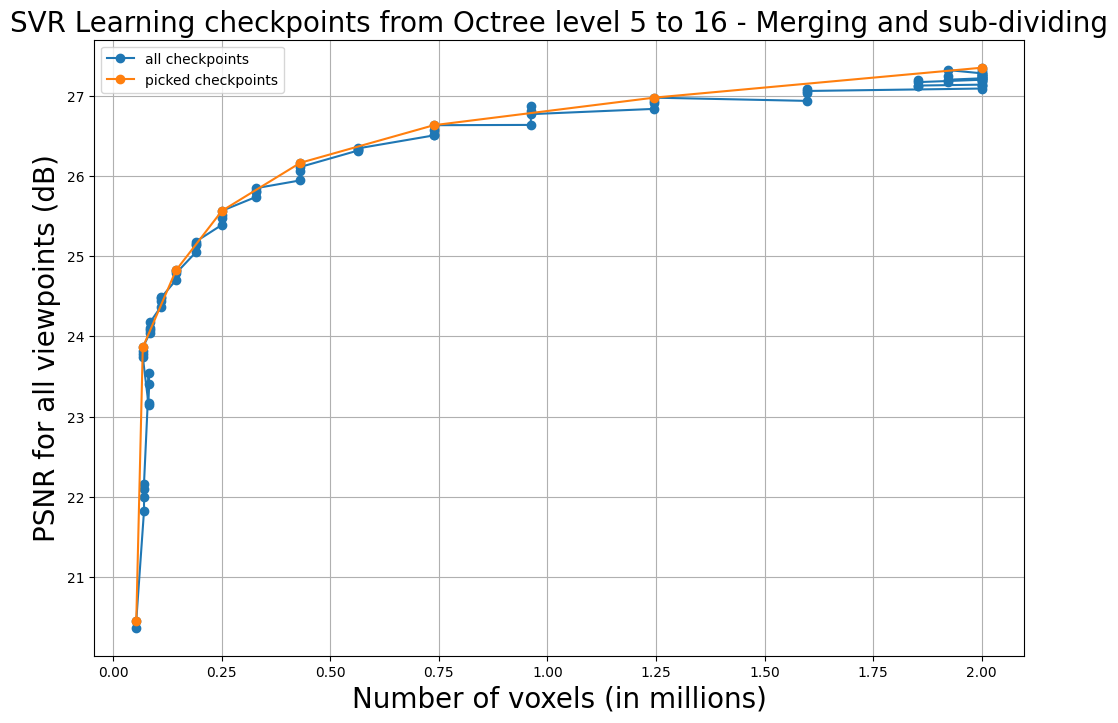

In [16]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(np.array(list_num_vox[2:])/1e6, list_psnr[2:], "o-", label="all checkpoints")
ax.plot(np.array(list_num_vox_picked)/1e6, list_psnr_picked, "o-", label="picked checkpoints")
ax.set_ylabel("PSNR for all viewpoints (dB)", fontsize=20)
ax.set_xlabel("Number of voxels (in millions)", fontsize=20) 
# ax.set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]) 

plt.title("SVR Learning checkpoints from Octree level 5 to 16 - Merging and sub-dividing", fontsize=20)
plt.legend()
plt.grid(True)
plt.show()

### 001

In [3]:
# iter = 3999 nvox = 53383 psnr = 20.455171800861184
# iter = 15999 nvox = 68384 psnr = 23.861671997851698
# iter = 26999 nvox = 144737 psnr = 24.82181125978562
# iter = 35999 nvox = 250556 psnr = 25.563771738778417
# iter = 42999 nvox = 431129 psnr = 26.16217433504914
# iter = 51999 nvox = 738494 psnr = 26.630531227057624
# iter = 59999 nvox = 1245585 psnr = 26.97370018154894
# iter = 87999 nvox = 1999998 psnr = 27.346640245272

#  iter003999_model, iter015999_model, iter026999_model, iter035999_model, iter042999_model, iter051999_model, iter059999_model, iter087999_model,

In [4]:
source_path = "/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/"
scene_dataset = Scene(
    source_path, image_dir_name="images",
    res_downscale=8.0, res_width=0,
    encoder_view_every=20
)

train_views = scene_dataset.get_train_views()
test_views = scene_dataset.get_encoder_views()
len(train_views), len(test_views)


Read dataset in COLMAP format.
Done reading and creating views: 279 train views and 14 encoding views


(279, 14)

In [13]:
low_res = DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter003999_model.pt")
high_res= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter015999_model.pt")

approx_attribute_field = high_res.apply_A_transpose(
    low_res,
    low_res.voxel_attribute_field,
    scene_dataset,
    optim_opt={
        "lr": 0.001,
        "num_scene_loop": 30
    }
)


Apply_A_transpose: loop = (0, 0) iter = 0 psnr=15.00607967376709
Apply_A_transpose: loop = (1, 221) iter = 500 psnr=21.176412105560303
Apply_A_transpose: loop = (3, 163) iter = 1000 psnr=24.08686876296997
Apply_A_transpose: loop = (5, 105) iter = 1500 psnr=25.602612495422363
Apply_A_transpose: loop = (7, 47) iter = 2000 psnr=26.378231048583984
Apply_A_transpose: loop = (8, 268) iter = 2500 psnr=26.58958911895752
Apply_A_transpose: loop = (10, 210) iter = 3000 psnr=26.847000122070312
Apply_A_transpose: loop = (12, 152) iter = 3500 psnr=26.735782623291016
Apply_A_transpose: loop = (14, 94) iter = 4000 psnr=26.894185543060303
Apply_A_transpose: loop = (16, 36) iter = 4500 psnr=26.960740089416504
Apply_A_transpose: loop = (17, 257) iter = 5000 psnr=26.790626049041748
Apply_A_transpose: loop = (19, 199) iter = 5500 psnr=26.955418586730957
Apply_A_transpose: loop = (21, 141) iter = 6000 psnr=26.901702880859375
Apply_A_transpose: loop = (23, 83) iter = 6500 psnr=26.979918479919434
Apply_A_tra

In [14]:

list_mse = []
for view in train_views:
    tensor_img = high_res.apply_phi_with_F(approx_attribute_field, view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    # img_true     = im_tensor2np(view.rendered_true)

    tensor_img_target = low_res.apply_phi(view).detach()
    img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 27.188078797362138


In [15]:
list_mse = []
for view in train_views:
    tensor_img = high_res.apply_phi_with_F(approx_attribute_field, view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    # img_true     = im_tensor2np(view.rendered_true)

    tensor_img_target = high_res.apply_phi(view).detach()
    img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 22.41206243472485


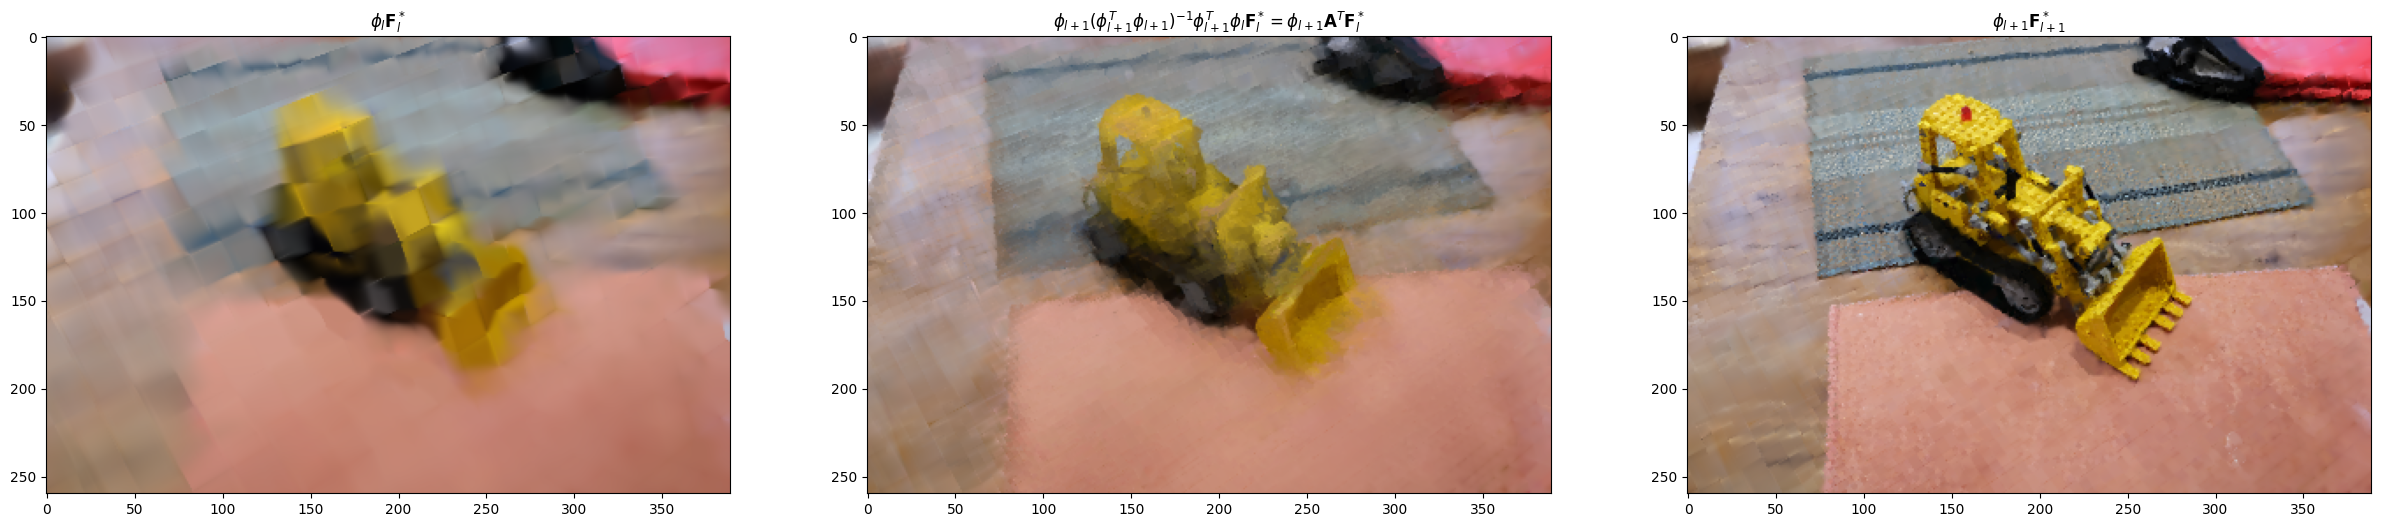

In [16]:
i=50
rendered_img_low = low_res.apply_phi(train_views[i]).cpu().numpy()
rendered_img_high = high_res.apply_phi(train_views[i]).cpu().numpy()
rendered_img_low_approx = high_res.apply_phi_with_F(approx_attribute_field, train_views[i]).detach().cpu().numpy()

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))
ax[0].imshow(rendered_img_low)
ax[0].set_title(r"$\phi_l \mathbf{F}_l^*$")
ax[1].imshow(rendered_img_low_approx)
ax[1].set_title(r"$\phi_{l+1} (\phi_{l+1}^T\phi_{l+1})^{-1} \phi_{l+1}^T\phi_l \mathbf{F}_l^* = \phi_{l+1} \mathbf{A}^T \mathbf{F}_l^*$")
ax[2].imshow(rendered_img_high)
ax[2].set_title(r"$\phi_{l+1} \mathbf{F}_{l+1}^*$")

# err = np.clip(np.abs(rendered_img_low_approx-rendered_img_low) / rendered_img_low_approx, 0.0, 1.0)
# ax[3].imshow(err)

plt.show()

### 003

In [4]:
# iter = 3999 nvox = 53383 psnr = 20.455171800861184
# iter = 15999 nvox = 68384 psnr = 23.861671997851698
# iter = 26999 nvox = 144737 psnr = 24.82181125978562
# iter = 35999 nvox = 250556 psnr = 25.563771738778417
# iter = 42999 nvox = 431129 psnr = 26.16217433504914
# iter = 51999 nvox = 738494 psnr = 26.630531227057624
# iter = 59999 nvox = 1245585 psnr = 26.97370018154894
# iter = 87999 nvox = 1999998 psnr = 27.346640245272

#  iter003999_model, iter015999_model, iter026999_model, iter035999_model, iter042999_model, iter051999_model, iter059999_model, iter087999_model,

In [ ]:
torch.cuda.empty_cache()
encoder = MultiScaleSplatsEncoder(
    scene_dataset_source_path="/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/",
    list_density_field_paths=[
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter003999_model.pt",
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter015999_model.pt", # 1
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter026999_model.pt", # 2
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter035999_model.pt", # 3
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter042999_model.pt", # 4
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter051999_model.pt", # 5
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter059999_model.pt", # 6
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt", # 7
    ],
    num_sample_per_voxel=1,
    scene_loader_opt={
        "res_downscale": 8,
        "res_width": 0,
        "encoder_view_every": 20
    },
    A_transpose_opt={
        "lr": 0.001,
        "num_scene_loop": 30,
    },
    rotation_opt={
        "max_degree": 5,
        "muy_phi": 1.0,
    },
    encoding_opts={
        "lr": 0.005,
        "lambda_l1": 0.0,
        "num_loop": 5,
        "update_frequency": None
    }
)

Read dataset in COLMAP format.
Done reading and creating views: 279 train views and 14 encoding views


In [6]:
all_quantized_coefs, decoded_attribute = encoder.testing_encoding()

Encoding level=1
Apply_A_transpose: loop = 0 iter = 0 psnr=14.048992156982422
Apply_A_transpose: loop = 0 iter = 100 psnr=17.46314239501953
Apply_A_transpose: loop = 0 iter = 200 psnr=19.11639976501465
Apply_A_transpose: loop = 1 iter = 300 psnr=17.29847526550293
Apply_A_transpose: loop = 1 iter = 400 psnr=18.24886131286621
Apply_A_transpose: loop = 1 iter = 500 psnr=24.743202209472656
Apply_A_transpose: loop = 2 iter = 600 psnr=21.45089340209961
Apply_A_transpose: loop = 2 iter = 700 psnr=23.911428451538086
Apply_A_transpose: loop = 2 iter = 800 psnr=23.561870574951172
Apply_A_transpose: loop = 3 iter = 900 psnr=23.243131637573242
Apply_A_transpose: loop = 3 iter = 1000 psnr=22.463558197021484
Apply_A_transpose: loop = 3 iter = 1100 psnr=25.230581283569336
Apply_A_transpose: loop = 4 iter = 1200 psnr=26.3084716796875
Apply_A_transpose: loop = 4 iter = 1300 psnr=20.915014266967773
Apply_A_transpose: loop = 5 iter = 1400 psnr=23.784870147705078
Apply_A_transpose: loop = 5 iter = 1500 ps

In [47]:
for l, coefs in enumerate(all_quantized_coefs):
    min_val = torch.min(coefs, dim=0)[0]
    avg_val = torch.mean(coefs, dim=0)[0]
    max_val = torch.max(coefs, dim=0)[0]

    print(f"level={l} min_val={min_val.cpu().numpy()} avg_val={avg_val.cpu().numpy()} max_val={max_val.cpu().numpy()}")

level=0 min_val=[-3.7670963 -3.8294294 -3.1885269] avg_val=0.0068028816021978855 max_val=[3.4714627 3.0749774 3.7927861]
level=1 min_val=[-2.673486  -2.1632044 -1.8934585] avg_val=-0.00605982169508934 max_val=[1.6994952 1.276602  1.7866479]
level=2 min_val=[-1.9374981 -1.2753897 -1.1414398] avg_val=-0.00506175821647048 max_val=[1.1038102 0.9582167 1.1712182]
level=3 min_val=[-0.8464627 -1.0752939 -0.896135 ] avg_val=0.0012234436580911279 max_val=[0.8375485  0.71623343 1.4425658 ]
level=4 min_val=[-0.8971123 -0.9356184 -1.2398195] avg_val=-0.0007487978436984122 max_val=[0.976269  1.585352  1.5470306]
level=5 min_val=[-0.9797586  -0.7975791  -0.95572186] avg_val=0.0012359835673123598 max_val=[1.3364999  0.85426337 1.7300631 ]
level=6 min_val=[-0.77694863 -1.0153859  -0.8235656 ] avg_val=0.0012989366659894586 max_val=[1.1494939 1.0272834 2.0105069]


In [48]:
for l, coefs in enumerate(all_quantized_coefs):
    min_val = torch.min(torch.abs(coefs), dim=0)[0]
    avg_val = torch.mean(torch.abs(coefs), dim=0)[0]
    max_val = torch.max(torch.abs(coefs), dim=0)[0]

    print(f"level={l} min_abs_val={min_val.cpu().numpy()} avg_abs_val={avg_val.cpu().numpy()} max_abs_val={max_val.cpu().numpy()}")

level=0 min_abs_val=[5.2554345e-08 2.4564778e-07 1.2147892e-07] avg_abs_val=0.20566299557685852 max_abs_val=[3.7670963 3.8294294 3.7927861]
level=1 min_abs_val=[8.672598e-09 5.848564e-08 9.927296e-09] avg_abs_val=0.08569527417421341 max_abs_val=[2.673486  2.1632044 1.8934585]
level=2 min_abs_val=[1.6767819e-08 4.9402608e-08 3.2477733e-08] avg_abs_val=0.047839343547821045 max_abs_val=[1.9374981 1.2753897 1.1712182]
level=3 min_abs_val=[8.7883176e-09 3.3484555e-09 1.6114351e-08] avg_abs_val=0.031839191913604736 max_abs_val=[0.8464627 1.0752939 1.4425658]
level=4 min_abs_val=[2.8815302e-08 2.3205954e-08 4.7642046e-09] avg_abs_val=0.023749811574816704 max_abs_val=[0.976269  1.585352  1.5470306]
level=5 min_abs_val=[2.116403e-10 3.951383e-09 1.911766e-08] avg_abs_val=0.01698077656328678 max_abs_val=[1.3364999  0.85426337 1.7300631 ]
level=6 min_abs_val=[2.0504152e-09 1.8503087e-09 1.1884249e-08] avg_abs_val=0.013276607729494572 max_abs_val=[1.1494939 1.0272834 2.0105069]


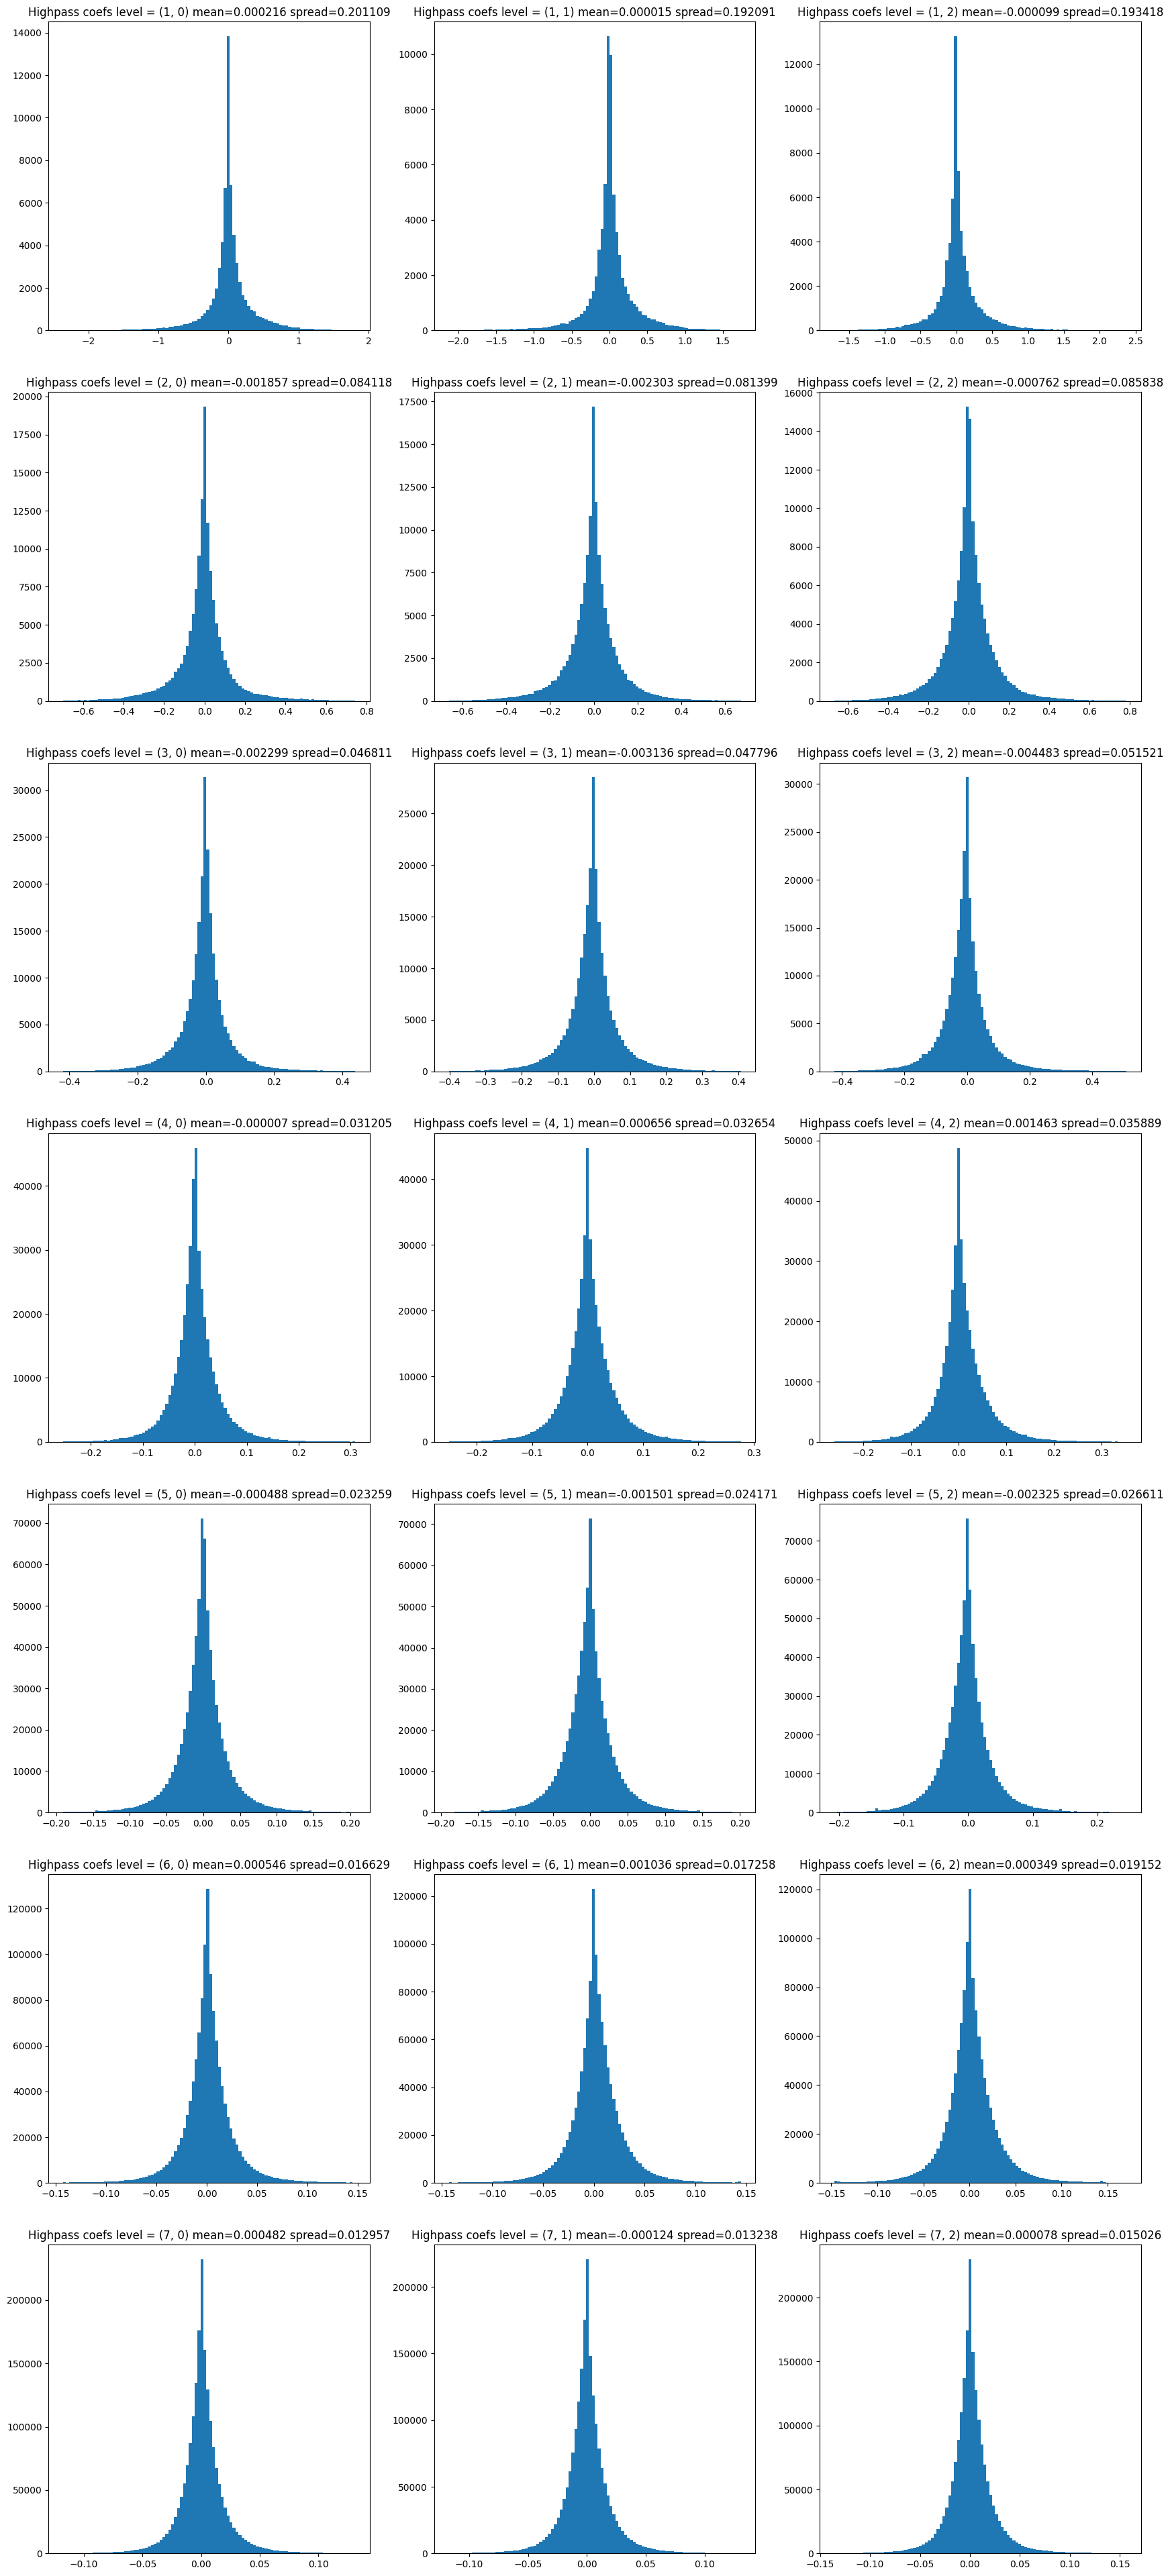

In [53]:

fig, ax = plt.subplots(ncols=3, nrows=7, figsize=(21, 7*7))
for l, coefs in enumerate(all_quantized_coefs):
    for i in [0, 1, 2]:
        y = coefs[:, i].cpu().numpy()
        ind = (y > np.percentile(y, 0.1)) & (y < np.percentile(y, 99.9))

        a = np.median(y[ind])
        b = np.mean(np.abs(y[ind] - a))

        ax[l][i].hist(y[ind], bins=100)
        ax[l][i].set_title(f"Highpass coefs level = {l+1, i} mean={a:04f} spread={b:04f}")
plt.show()

In [ ]:
train_views = encoder.scene_dataset.get_train_views()
test_views = encoder.scene_dataset.get_encoder_views()

In [54]:
ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")


def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)


list_mse = []
for view in train_views:
    tensor_img = ref_denfield.apply_phi_with_F(decoded_attribute, view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    tensor_img_target = ref_denfield.apply_phi(view).detach()
    img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 66.90176952444995


In [55]:
rendered_img.shape

(260, 389, 3)

In [21]:
ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")

def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

list_mse = []
for view in train_views:
    tensor_img = ref_denfield.apply_phi_with_F(decoded_attribute, view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    img_target     = im_tensor2np(view.rendered_true)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 27.346742133634066


In [22]:
ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")

def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

list_mse = []
for view in test_views:
    tensor_img = ref_denfield.apply_phi_with_F(decoded_attribute, view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    img_target     = im_tensor2np(view.rendered_true)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 26.75997506157732


### 003b


In [3]:
source_path = "/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/"
scene_dataset = Scene(
    source_path, image_dir_name="images",
    res_downscale=8.0, res_width=0,
    encoder_view_every=20
)

Read dataset in COLMAP format.
Done reading and creating views: 279 train views and 14 encoding views


In [4]:
lowest_field = DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter003999_model.pt")

p_log2_delta = torch.nn.Parameter(torch.full(
    [1], np.log2(0.005), 
    dtype=torch.float32, device="cuda"
))

p_coefs = torch.nn.Parameter(torch.full(
    [lowest_field.num_voxels, 3], 0.0, 
    dtype=torch.float32, device="cuda"
))
p_log2_spread = torch.nn.Parameter(torch.full(
    [1, 3], np.log2(0.9), 
    dtype=torch.float32, device="cuda"
))



encoded_coefs = lowest_field.encoding_attribute_field(
    (1e-5, p_log2_delta, p_coefs, p_log2_spread),
    lowest_field.voxel_attribute_field,
    scene_dataset,
    rotation_opt={
        "max_degree": 2,
        "muy_phi": 0.9,
    },
    encoding_opts={
        "lr": 0.005,
        "num_loop": 45,
    },
)

Start Encoding Process custom_encoding_opts={'lr': 0.005, 'num_loop': 45}
Encoding_attribute_field: TESTING loop = (0, 0) iter = 0 psnr=5.907072424888611 psnr_delta_field=6.25587272644043 rate=8.489684104919434 spread=[[0.8969 0.8969 0.8969]]
Encoding_attribute_field: TESTING loop = (0, 100) iter = 100 psnr=6.111167669296265 psnr_delta_field=12.969690322875977 rate=8.7437744140625 spread=[[0.6531 0.6517 0.6489]]
Encoding_attribute_field: TESTING loop = (0, 200) iter = 200 psnr=6.307657957077026 psnr_delta_field=14.517601013183594 rate=8.95979118347168 spread=[[0.5162 0.5085 0.4967]]
Encoding_attribute_field: TESTING loop = (1, 21) iter = 300 psnr=6.484129428863525 psnr_delta_field=11.024141311645508 rate=9.19803524017334 spread=[[0.4546 0.4364 0.4112]]
Encoding_attribute_field: TESTING loop = (1, 121) iter = 400 psnr=6.645143628120422 psnr_delta_field=15.895257949829102 rate=9.513843536376953 spread=[[0.447  0.4164 0.3753]]
Encoding_attribute_field: TESTING loop = (1, 221) iter = 500 p

In [6]:
torch.exp2(p_log2_delta)

tensor([    0.0001], device='cuda:0', grad_fn=<Exp2Backward0>)

In [7]:
min_val = torch.min(torch.abs(encoded_coefs), dim=0)[0]
avg_val = torch.abs(encoded_coefs).mean(dim=0)
max_val = torch.max(torch.abs(encoded_coefs), dim=0)[0]

print(f" min_abs_val={min_val.cpu().numpy()} avg_abs_val={avg_val.cpu().numpy()} max_abs_val={max_val.cpu().numpy()}")

 min_abs_val=[0. 0. 0.] avg_abs_val=[1.5152 1.3247 1.1432] max_abs_val=[48.669  41.3258 37.2949]


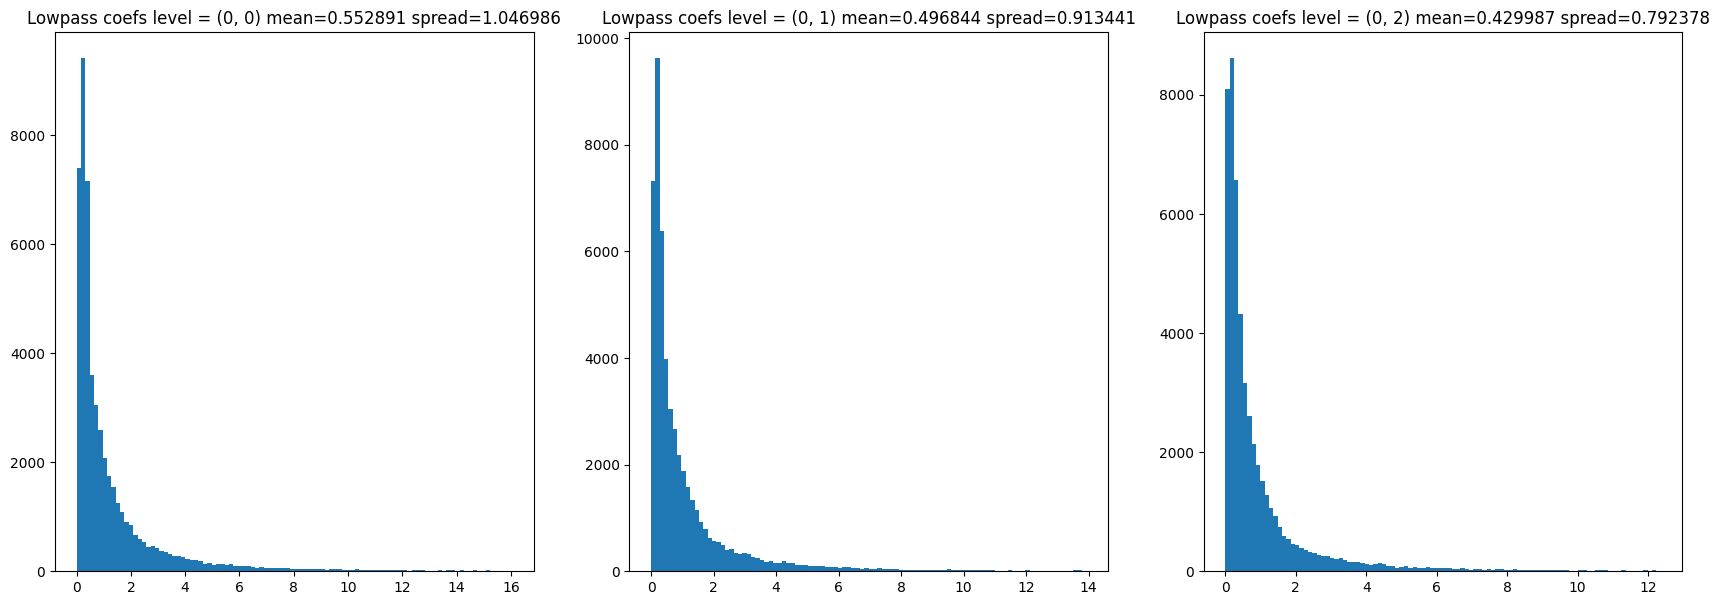

In [8]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(21, 7))
for i in [0, 1, 2]:
    y = encoded_coefs[:, i].cpu().numpy()
    ind = (y > np.percentile(y, 0.01)) & (y < np.percentile(y, 99))

    a = np.median(y[ind])
    b = np.mean(np.abs(y[ind] - a))

    ax[i].hist(y[ind], bins=100)
    ax[i].set_title(f"Lowpass coefs level = {0, i} mean={a:04f} spread={b:04f}")
plt.show()

In [9]:
decoded_attribute_field = lowest_field.decoding_attribute_field(
    encoded_coefs,
    scene_dataset,
    rotation_opt={
        "max_degree": 2,
        "muy_phi": 0.9,
    },
)

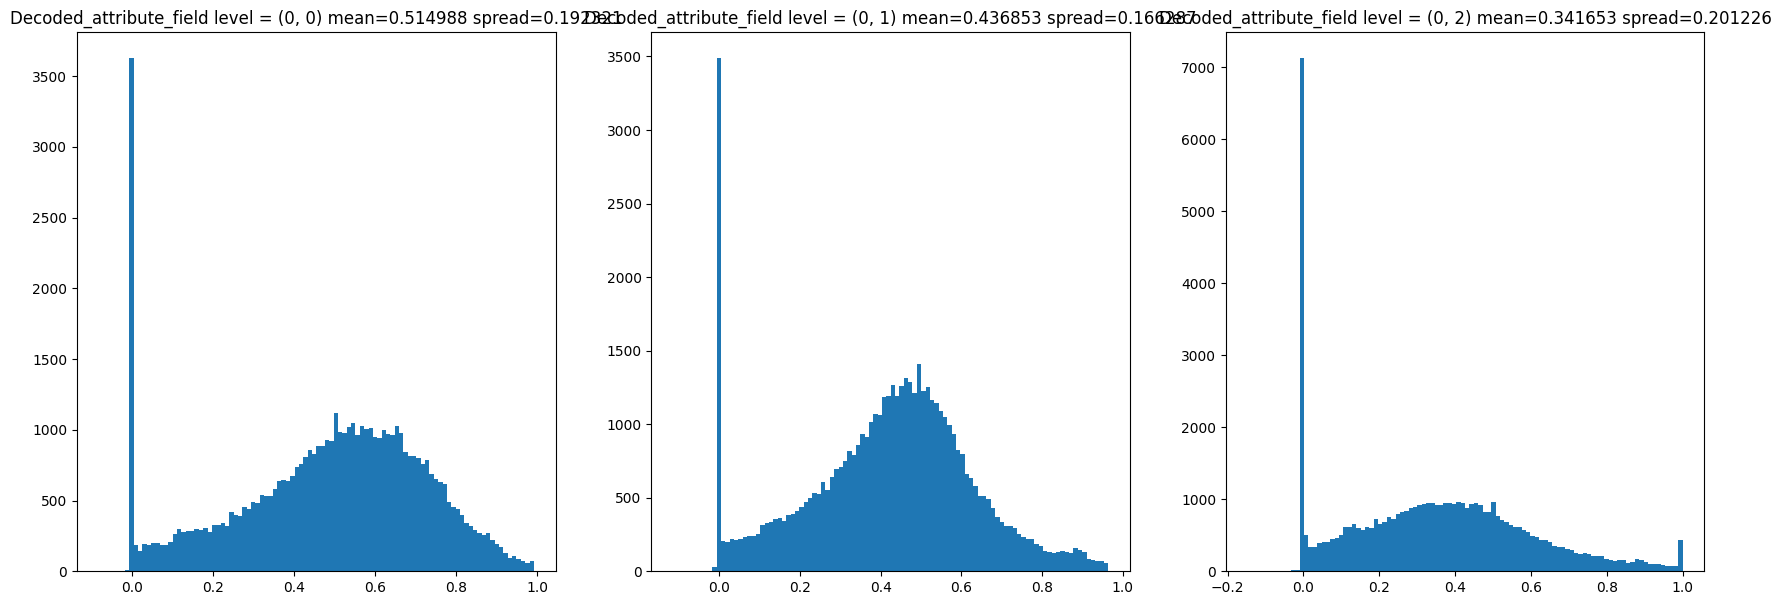

In [10]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(21, 7))
for i in [0, 1, 2]:
    y = decoded_attribute_field[:, i].cpu().numpy()
    ind = (y > np.percentile(y, 0.01)) & (y < np.percentile(y, 99))

    a = np.median(y[ind])
    b = np.mean(np.abs(y[ind] - a))

    ax[i].hist(y[ind], bins=100)
    ax[i].set_title(f"Decoded_attribute_field level = {0, i} mean={a:04f} spread={b:04f}")
plt.show()

In [11]:
train_views = scene_dataset.get_train_views()
test_views = scene_dataset.get_encoder_views()
# ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")
# temp_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter015999_model.pt")

def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)


list_mse = []
for view in test_views:
    tensor_img = lowest_field.apply_phi_with_F(decoded_attribute_field, view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    img_target     = im_tensor2np(view.rendered_true)
    # tensor_img_target = ref_denfield.apply_phi(view).detach()
    # img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 19.64648753317469


In [12]:
train_views = scene_dataset.get_train_views()
test_views = scene_dataset.get_encoder_views()
ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")

def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)


list_mse = []
for view in test_views:
    tensor_img = lowest_field.apply_phi_with_F(decoded_attribute_field, view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    # img_target     = im_tensor2np(view.rendered_true)
    tensor_img_target = ref_denfield.apply_phi(view).detach()
    img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 19.060010204179562


In [13]:
train_views = scene_dataset.get_train_views()
test_views = scene_dataset.get_encoder_views()
ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")

def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)


list_mse = []
for view in test_views:
    tensor_img = lowest_field.apply_phi(view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    # img_target     = im_tensor2np(view.rendered_true)
    tensor_img_target = ref_denfield.apply_phi(view).detach()
    img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 19.46201783080411


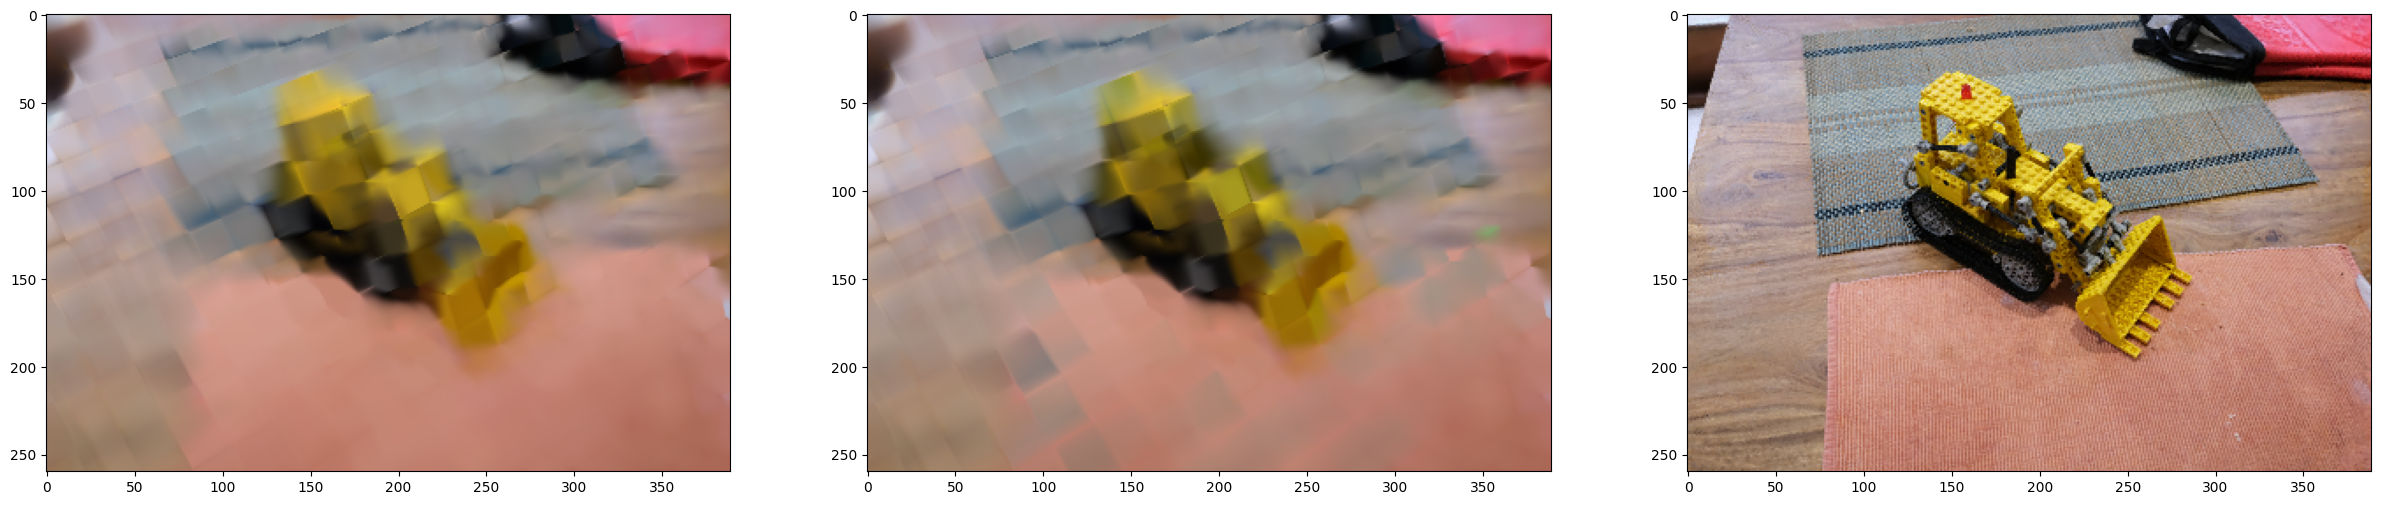

In [14]:
i=50
rendered_img_low = lowest_field.apply_phi(train_views[i]).cpu().numpy()
rendered_img_high = ref_denfield.apply_phi(train_views[i]).cpu().numpy()
rendered_img_low_approx = lowest_field.apply_phi_with_F(decoded_attribute_field, train_views[i]).cpu().numpy()

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))
ax[0].imshow(rendered_img_low)
ax[1].imshow(rendered_img_low_approx)
ax[2].imshow(rendered_img_high)

# err = np.clip(np.abs(rendered_img_low_approx-rendered_img_low) / rendered_img_low_approx, 0.0, 1.0)
# ax[3].imshow(err)

plt.show()

### 004

In [9]:
torch.cuda.empty_cache()
encoder = MultiScaleSplatsEncoder(
    scene_dataset_source_path="/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/",
    list_density_field_paths=[
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter003999_model.pt",
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter015999_model.pt", # 1
    ],
    num_sample_per_voxel=1,
    deltaQ=0.005,
    lambda_rate=0.00001,
    list_spread_b_init=[1.0, 0.2, 0.085, 0.05, 0.035, 0.025, 0.02, 0.015], 
    scene_loader_opt={
        "res_downscale": 8,
        "res_width": 0,
        "encoder_view_every": 20
    },
    A_transpose_opt={
        "lr": 0.001,
        "num_scene_loop": 30,
    },
    rotation_opt={
        "max_degree": 5,
        "muy_phi": 1.0,
    },
    encoding_opts={
        "lr": 0.005,
        "num_loop": 5,
    }
)

Read dataset in COLMAP format.
Done reading and creating views: 279 train views and 14 encoding views


In [ ]:
list_quantized_coefs, decoded_attribute = encoder.encoding()

Start Encoding Process custom_encoding_opts={'lr': 0.005, 'num_loop': 5, 'deltaQ': 2, 'lambda_rate': 0.0, 'spread_init': 1.0}
Encoding_attribute_field: TESTING loop = (0, 0) iter = 0 psnr=5.907072424888611 psnr_delta_field=6.25587272644043 rate=0.007022451143711805 spread=[[1. 1. 1.]]
Encoding_attribute_field: TESTING loop = (0, 100) iter = 100 psnr=6.168383955955505 psnr_delta_field=14.613547325134277 rate=0.25018107891082764 spread=[[1. 1. 1.]]
Encoding_attribute_field: TESTING loop = (0, 200) iter = 200 psnr=6.4204442501068115 psnr_delta_field=16.374189376831055 rate=0.33253979682922363 spread=[[1. 1. 1.]]
Encoding_attribute_field: TESTING loop = (1, 21) iter = 300 psnr=6.653075814247131 psnr_delta_field=17.4078369140625 rate=0.3907387852668762 spread=[[1. 1. 1.]]
Encoding_attribute_field: TESTING loop = (1, 121) iter = 400 psnr=6.873617768287659 psnr_delta_field=18.175025939941406 rate=0.43779438734054565 spread=[[1. 1. 1.]]
Encoding_attribute_field: TESTING loop = (1, 221) iter = 

In [ ]:
train_views = encoder.scene_dataset.get_train_views()
test_views = encoder.scene_dataset.get_encoder_views()
ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")

temp_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter015999_model.pt")

def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)


list_mse = []
for view in train_views:
    tensor_img = temp_denfield.apply_phi_with_F(decoded_attribute, view).detach()a
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    img_target     = im_tensor2np(view.rendered_true)
    # tensor_img_target = ref_denfield.apply_phi(view).detach()
    # img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 23.816195980649447


In [6]:
train_views = encoder.scene_dataset.get_train_views()
test_views = encoder.scene_dataset.get_encoder_views()
ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")

temp_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter015999_model.pt")

def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)


list_mse = []
for view in train_views:
    tensor_img = temp_denfield.apply_phi(view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    img_target     = im_tensor2np(view.rendered_true)
    # tensor_img_target = ref_denfield.apply_phi(view).detach()
    # img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 23.861671997851698


### 005

In [ ]:
# iter = 3999 nvox = 53383 psnr = 20.455171800861184
# iter = 15999 nvox = 68384 psnr = 23.861671997851698
# iter = 26999 nvox = 144737 psnr = 24.82181125978562
# iter = 35999 nvox = 250556 psnr = 25.563771738778417
# iter = 42999 nvox = 431129 psnr = 26.16217433504914
# iter = 51999 nvox = 738494 psnr = 26.630531227057624
# iter = 59999 nvox = 1245585 psnr = 26.97370018154894
# iter = 87999 nvox = 1999998 psnr = 27.346640245272

#  iter003999_model, iter015999_model, iter026999_model, iter035999_model, iter042999_model, iter051999_model, iter059999_model, iter087999_model,

torch.cuda.empty_cache()
encoder = MultiScaleSplatsEncoder(
    scene_dataset_source_path="/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/",
    list_density_field_paths=[
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter003999_model.pt",
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter015999_model.pt", # 1
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter026999_model.pt", # 2
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter035999_model.pt", # 3
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter042999_model.pt", # 4
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter051999_model.pt", # 5
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter059999_model.pt", # 6
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt", # 7
    ],
    num_sample_per_voxel=1,
    deltaQ=0.001,
    lambda_rate=0.0,
    list_spread_b_init=[1.0, 0.2, 0.085, 0.05, 0.035, 0.025, 0.02, 0.015], 
    scene_loader_opt={
        "res_downscale": 8,
        "res_width": 0,
        "encoder_view_every": 20
    },
    A_transpose_opt={
        "lr": 0.001,
        "num_scene_loop": 30,
    },
    rotation_opt={
        "max_degree": 2,
        "muy_phi": 0.9,
    },
    encoding_opts={
        "lr": 0.001,
        "num_loop": 5,
        "dmode": "render_space" #coef_space / render_space
    },
    lowpass_rotation_opt = {
        "max_degree": 2,
        "muy_phi": 0.9,
    },
    lowpass_encoding_opts={
        "lr": 0.005,
        "num_loop": 5,
        "dmode": "render_space" #coef_space / render_space
    }
)

Read dataset in COLMAP format.
Done reading and creating views: 279 train views and 14 encoding views


In [4]:

checkpoint = torch.load("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/encoding_checkpoints/init_learning.pt", weights_only=True)
encoder.trainable_params.load_state_dict(checkpoint["trainable_parameters"])

<All keys matched successfully>

In [ ]:
output = encoder.encoding()

Start Encoding Process custom_encoding_opts={'lr': 0.01, 'num_loop': 5}
Encoding_attribute_field: TESTING loop = (0, 0) iter = 0 psnr=35.37619590759277 psnr_delta_field=33.89335250854492 rate=17.65786361694336 spread=[[1.0892 0.9418 0.8104]] deltaQ=[2.4891e-05] 
Encoding_attribute_field: TESTING loop = (0, 100) iter = 100 psnr=35.408291816711426 psnr_delta_field=43.073944091796875 rate=17.601043701171875 spread=[[1.0968 0.9482 0.8159]] deltaQ=[2.589e-05] 
Encoding_attribute_field: TESTING loop = (0, 200) iter = 200 psnr=35.453553199768066 psnr_delta_field=49.420623779296875 rate=17.534299850463867 spread=[[1.0968 0.9482 0.8159]] deltaQ=[2.7115e-05] 
Encoding_attribute_field: TESTING loop = (1, 21) iter = 300 psnr=35.50697088241577 psnr_delta_field=46.706260681152344 rate=17.449810028076172 spread=[[1.0968 0.9481 0.8159]] deltaQ=[2.8749e-05] 
Encoding_attribute_field: TESTING loop = (1, 121) iter = 400 psnr=35.56609630584717 psnr_delta_field=44.217227935791016 rate=17.34111976623535 spr

In [5]:
output = encoder.encoding()

Start Encoding Process custom_encoding_opts={'lr': 0.01, 'num_loop': 5}
Encoding_attribute_field: TESTING loop = (0, 0) iter = 0 psnr=35.37619590759277 psnr_delta_field=33.89335250854492 rate=17.652713775634766 spread=[[1.0892 0.9418 0.8104]] deltaQ=[2.4891e-05] 
Encoding_attribute_field: TESTING loop = (0, 100) iter = 100 psnr=32.45861768722534 psnr_delta_field=-18.82052230834961 rate=16.626052856445312 spread=[[1.0862 0.9259 0.791 ]] deltaQ=[4.9799e-05] 
Encoding_attribute_field: TESTING loop = (0, 200) iter = 200 psnr=33.075294494628906 psnr_delta_field=-22.126283645629883 rate=15.663729667663574 spread=[[1.1073 0.9472 0.8197]] deltaQ=[9.9567e-05] 
Encoding_attribute_field: TESTING loop = (1, 21) iter = 300 psnr=34.99399185180664 psnr_delta_field=-20.733278274536133 rate=14.694053649902344 spread=[[1.1199 0.9705 0.8416]] deltaQ=[0.0002] 
Encoding_attribute_field: TESTING loop = (1, 121) iter = 400 psnr=35.50191402435303 psnr_delta_field=-24.311058044433594 rate=13.687894821166992 sp

In [8]:
torch.save({"trainable_parameters": encoder.trainable_params.state_dict()}, "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/encoding_checkpoints/init_learning_render_space.pt")
checkpoints = {"trainable_parameters": encoder.trainable_params.state_dict()}

In [9]:
# all_quantized_coefs, decoded_attribute = encoder.extract_learned_encoding()
all_quantized_coefs, decoded_attribute = output

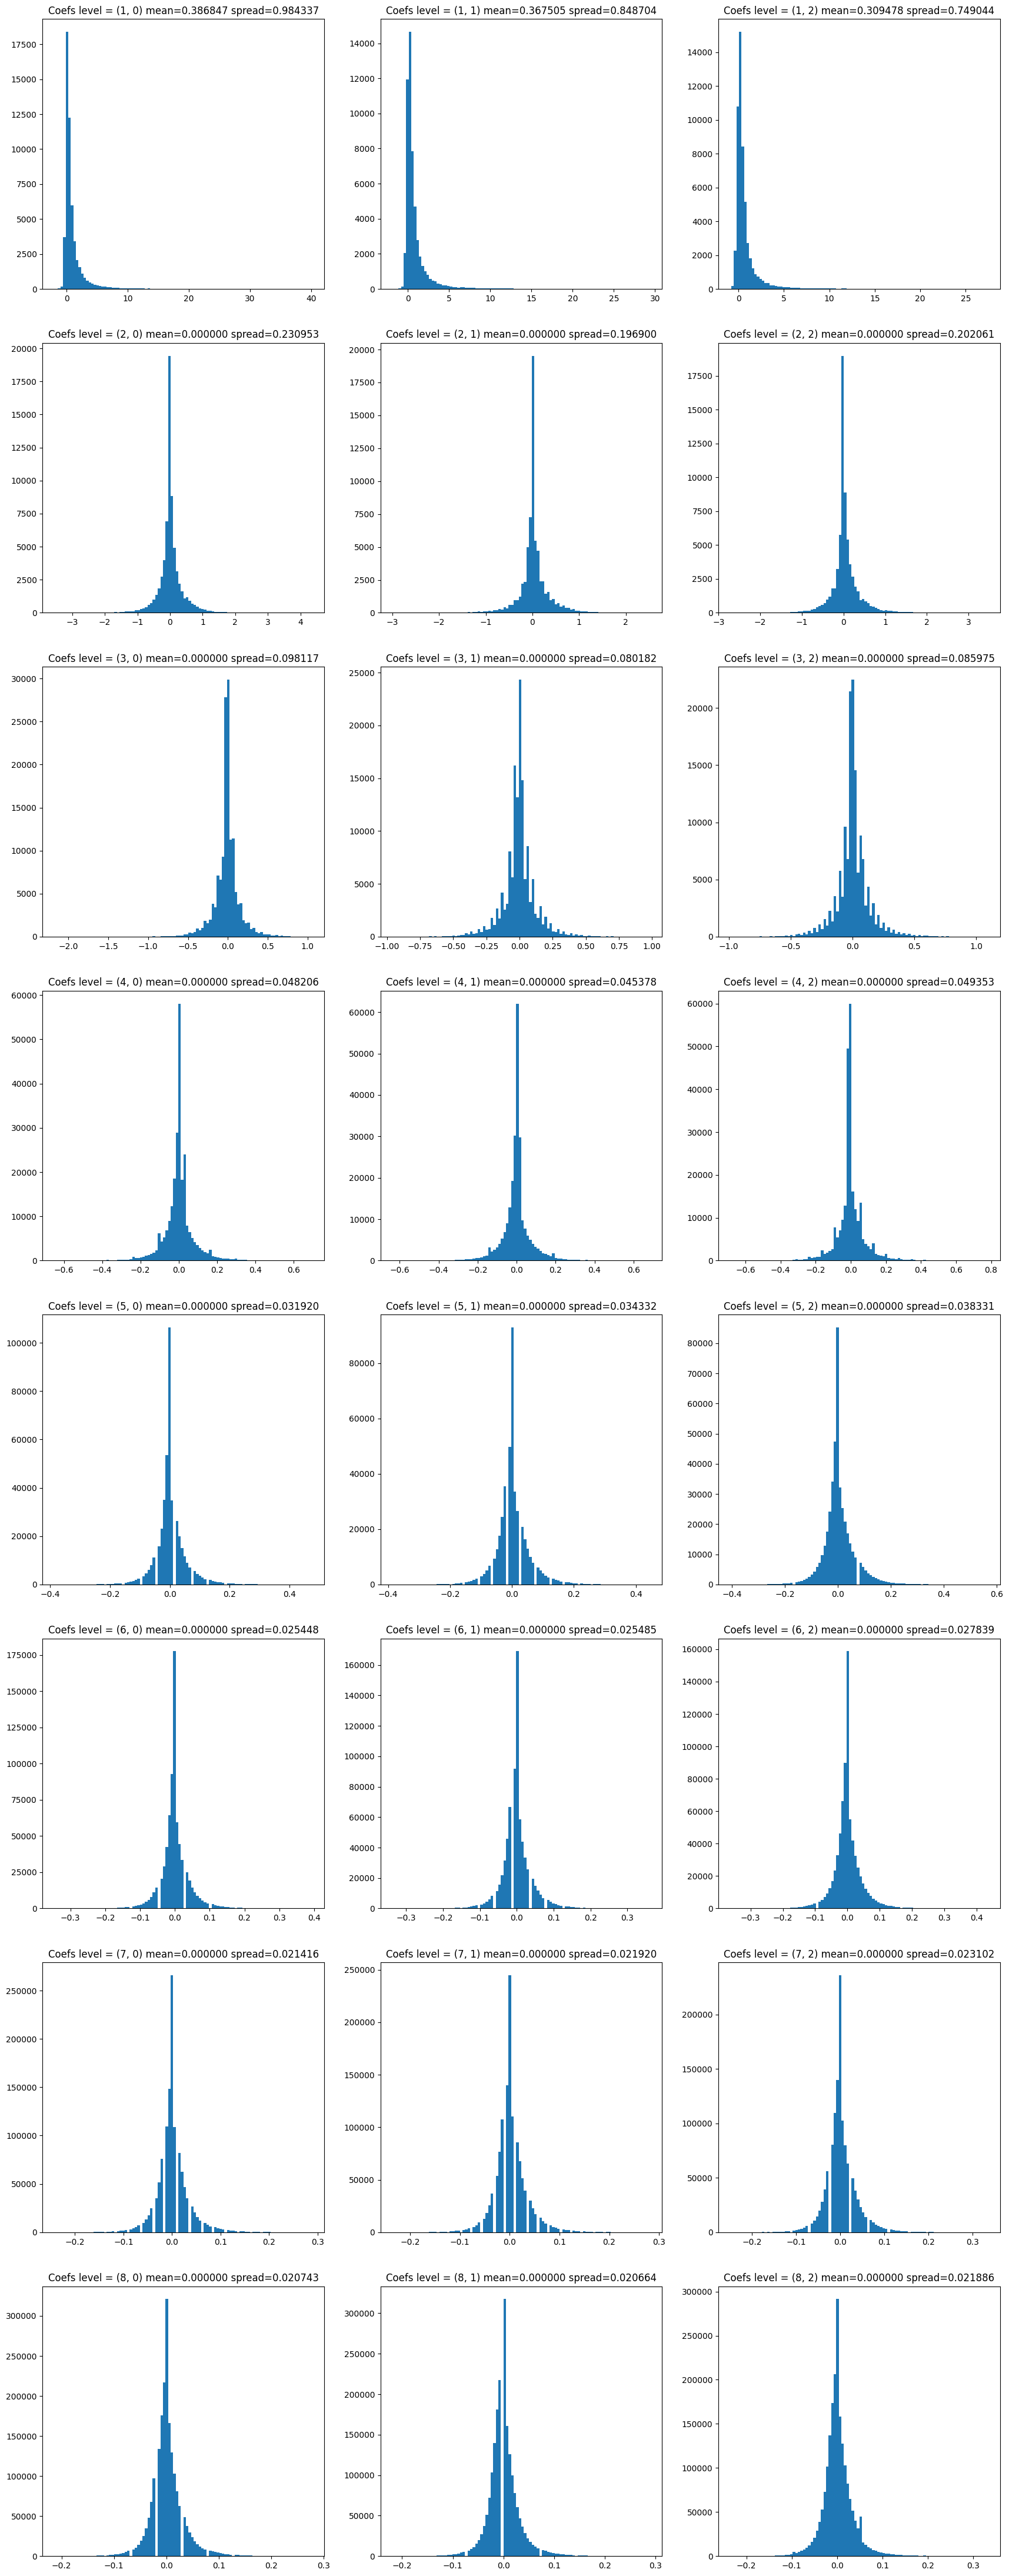

In [10]:

fig, ax = plt.subplots(ncols=3, nrows=8, figsize=(21, 7*8))
for l, coefs in enumerate(all_quantized_coefs):
    for i in [0, 1, 2]:
        y = coefs[:, i].cpu().numpy()
        ind = (y > np.percentile(y, 0.01)) & (y < np.percentile(y, 99.99))

        a = np.median(y[ind])
        b = np.mean(np.abs(y[ind] - a))

        ax[l][i].hist(y[ind], bins=100)
        ax[l][i].set_title(f"Coefs level = {l+1, i} mean={a:04f} spread={b:04f}")
plt.show()

In [11]:
train_views = encoder.scene_dataset.get_train_views()

In [12]:
ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")


def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)


list_mse = []
for view in encoder.scene_dataset.get_train_views():
    tensor_img = ref_denfield.apply_phi_with_F(decoded_attribute, view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    tensor_img_target = ref_denfield.apply_phi(view).detach()
    img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 22.89732338857441


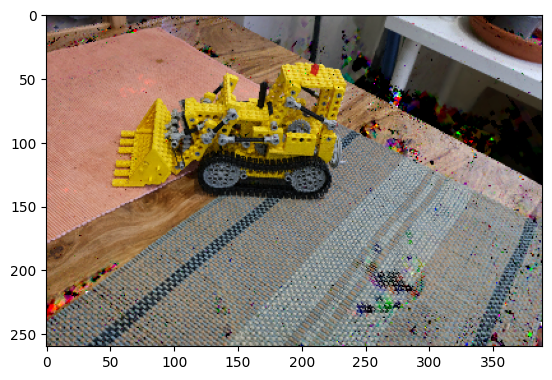

In [13]:
plt.imshow(rendered_img)

# END